# A geocloud tour — buckets, COG windows and a validated COG

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geotoolz/blob/main/docs/cloud/notebooks/geocloud_tour.ipynb)

You list and download objects from a public bucket, read windows of a Sentinel-2 COG without downloading it, and write an NDVI result as a validated COG. Every call shares one obstore client per bucket. The last section replays the workflow against an in-memory bucket, the way the tests run offline.

**What you'll learn:**

1. Register anonymous access per bucket with `geocloud.credentials.set_credentials`.
2. List, inspect and download objects with `geocloud.files` (`ls`, `info`, `download`).
3. Read COG windows with `geocloud.cog.CogSource`, fetching each tile once.
4. Write a COG with `geocloud.cog.write_cog` and check it with rasterio through `credentials.gdal_access`.
5. Mirror files into a mounted `MemoryStore` with `geocloud.files.sync` and `geocloud.store.mount`.

The package overview and the extras table are on the [geotoolz-cloud page](../index.md).

## Setup

On Colab the next cell installs `geotoolz-cloud[cog]`; locally, use the workspace environment (`make install`).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "geotoolz-cloud[cog] @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz-cloud",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from geocloud import credentials, files, store
from geocloud.cog import CogSource, write_cog
from georeader.geotensor import GeoTensor
from obstore.store import MemoryStore
from pyproj import Transformer
from rasterio.windows import Window, from_bounds

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,matplotlib,obstore,async_geotiff,rasterio,georeader,geocloud",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.16
IPython version      : 9.13.0

numpy        : 2.4.5
matplotlib   : 3.10.9
obstore      : 0.9.5
async_geotiff: 0.5.1
rasterio     : 1.5.0
georeader    : unknown
geocloud     : 0.3.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v80
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. Register the buckets

`set_credentials` registers options once per bucket; every later call under that root picks them up. Both buckets here are public, so `anonymous=True` sends unsigned requests. Each gets its own region. Nothing is written to `os.environ`.

In [4]:
credentials.set_credentials("s3://noaa-goes19", anonymous=True, region="us-east-1")
credentials.set_credentials("s3://sentinel-cogs", anonymous=True, region="us-west-2")
print(credentials.credential_roots())

['s3://noaa-goes19', 's3://sentinel-cogs']


## 2. List, inspect and download

`files.ls` lists a prefix. With `recursive=False` it lists one level, with sub-directories as `is_dir` entries. NOAA's GOES bucket is keyed by product, year, day of year and hour.

In [5]:
products: list[files.ObjectInfo] = files.ls("s3://noaa-goes19/", recursive=False)
print(f"{len(products)} products, e.g.", [p.uri.split("/")[-2] for p in products[:5]])

HOUR: str = "s3://noaa-goes19/ABI-L2-ACMM/2026/281/18/"  # 8 Oct 2026, 18 UTC
masks: list[files.ObjectInfo] = files.ls(HOUR)
print(f"{len(masks)} mesoscale clear sky masks in that hour; first three:")
for item in masks[:3]:
    print(
        f"  {item.size / 1e3:6.0f} kB  {item.last_modified:%H:%M:%S}  {item.uri.rsplit('/', 1)[-1]}"
    )

104 products, e.g. ['ABI-Flood-Day-Shapefiles', 'ABI-Flood-Day-TIF', 'ABI-Flood-Day', 'ABI-Flood-Hourly-Shapefiles', 'ABI-Flood-Hourly-TIF']
120 mesoscale clear sky masks in that hour; first three:
     364 kB  18:00:53  OR_ABI-L2-ACMM1-M6_G19_s20262811800286_e20262811800344_c20262811800455.nc
     364 kB  18:01:46  OR_ABI-L2-ACMM1-M6_G19_s20262811801258_e20262811801315_c20262811801410.nc
     364 kB  18:02:45  OR_ABI-L2-ACMM1-M6_G19_s20262811802258_e20262811802316_c20262811802408.nc


`files.info` reads one object's size, time and entity tag without fetching it. `files.download` streams it into a `.part` file and renames it when complete, so a failed transfer never leaves a truncated file. Downloads go to a temporary directory.

In [6]:
DATA: Path = Path(tempfile.mkdtemp(prefix="geocloud-"))

meta: files.ObjectInfo = files.info(masks[0].uri)
print(meta)

(DATA / "goes").mkdir()
local: Path = files.download(
    masks[0].uri, DATA / "goes"
)  # into a directory: keeps the name
print(local, f"{local.stat().st_size / 1e3:.0f} kB")

ObjectInfo(uri='s3://noaa-goes19/ABI-L2-ACMM/2026/281/18/OR_ABI-L2-ACMM1-M6_G19_s20262811800286_e20262811800344_c20262811800455.nc', size=363520, last_modified=datetime.datetime(2026, 10, 8, 18, 0, 53, tzinfo=datetime.timezone.utc), e_tag='"01f7ad6e5c4f0fa02422c2107b21b2e5"', is_dir=False)


/tmp/geocloud-zm7b01a2/goes/OR_ABI-L2-ACMM1-M6_G19_s20262811800286_e20262811800344_c20262811800455.nc 364 kB


## 3. Read COG windows

`CogSource.open` fetches the header of a remote COG once. `read_windows` then fetches every tile the windows touch exactly once, concurrently, and returns one `GeoTensor` per window. The scene is a nearly cloud-free Sentinel-2 L2A granule over Lake Tahoe, 19 September 2026.

In [7]:
SCENE: str = (
    "s3://sentinel-cogs/sentinel-s2-l2a-cogs/10/S/GJ/2026/9/S2A_10SGJ_20260919_0_L2A/"
)
assets: list[files.ObjectInfo] = files.ls(SCENE)
print([a.uri.rsplit("/", 1)[-1] for a in assets])

red: CogSource = CogSource.open(SCENE + "B04.tif")  # one header fetch
nir: CogSource = CogSource.open(SCENE + "B08.tif")
print(red.domain.shape, red.domain.crs, red.domain.res)

['AOT.tif', 'B01.tif', 'B02.tif', 'B03.tif', 'B04.tif', 'B05.tif', 'B06.tif', 'B07.tif', 'B08.tif', 'B09.tif', 'B11.tif', 'B12.tif', 'B8A.tif', 'L2A_PVI.tif', 'S2A_10SGJ_20260919_0_L2A.json', 'SCL.tif', 'TCI.tif', 'WVP.tif', 'granule_metadata.xml', 'preview.jpg', 'tileinfo_metadata.json']


(1, 10980, 10980) EPSG:32610 (10.0, 10.0)


Turn a lon/lat box around the lake into a pixel window of the 10 m grid, and read it from both bands. A second B04 window overlaps the first; the tiles they share are fetched once.

In [8]:
to_utm: Transformer = Transformer.from_crs("EPSG:4326", red.domain.crs, always_xy=True)
west, south = to_utm.transform(-120.26, 38.88)
east, north = to_utm.transform(-119.88, 39.28)
lake: Window = (
    from_bounds(west, south, east, north, red.domain.transform)
    .round_offsets()
    .round_lengths()
)
shifted: Window = Window(lake.col_off + 512, lake.row_off, lake.width, lake.height)
print(lake)

b04, b04_shifted = red.read_windows([lake, shifted])  # 2 × (1, h, w) uint16
(b08,) = nir.read_windows([lake])  #                  1 × (1, h, w) uint16
print(b04.shape, b04_shifted.shape, b04.dtype, b04.crs, b04.fill_value_default)

Window(col_off=3772, row_off=4755, width=3144, height=4546)


(1, 4546, 3144) (1, 4546, 3144) uint16 EPSG:32610 0


## 4. Compute NDVI and write a COG

NDVI is a float computation on the two windows. Sentinel-2 marks no data with `0`, so those pixels become `NaN`.

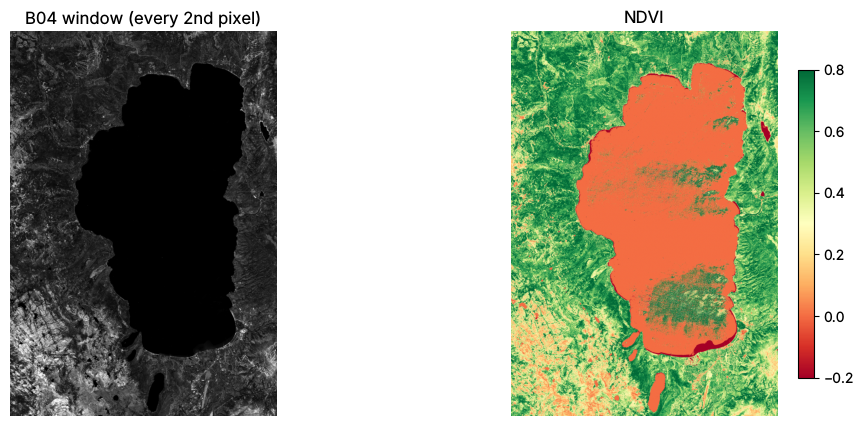

In [9]:
r: np.ndarray = np.asarray(b04, dtype="float32")  # (1, h, w) uint16 → (1, h, w) float32
n: np.ndarray = np.asarray(b08, dtype="float32")  # (1, h, w) uint16 → (1, h, w) float32
valid: np.ndarray = (r > 0) & (n > 0)  #            (1, h, w) bool
ndvi_values: np.ndarray = np.where(
    valid, (n - r) / (n + r), np.nan
)  # (1, h, w) float32
ndvi: GeoTensor = GeoTensor(
    ndvi_values.astype("float32"),
    transform=b04.transform,
    crs=b04.crs,
    fill_value_default=np.nan,
    attrs={"band_names": ("ndvi",)},
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.asarray(b04)[0, ::2, ::2], cmap="gray", vmin=0, vmax=3000)
axes[0].set_title("B04 window (every 2nd pixel)")
im = axes[1].imshow(np.asarray(ndvi)[0, ::2, ::2], cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[1].set_title("NDVI")
fig.colorbar(im, ax=axes[1], shrink=0.8)
for ax in axes:
    ax.set_axis_off()
plt.show()

`write_cog` builds the COG in a temporary directory, checks it, then renames it into place. The defaults follow the dtype: a floating-point predictor, `average` overviews and a `NaN` nodata for this `float32` NDVI.

In [10]:
out: Path = Path(write_cog(ndvi, DATA / "ndvi_tahoe.tif", compress="zstd"))
print(out, f"{out.stat().st_size / 1e6:.2f} MB")

/tmp/geocloud-zm7b01a2/ndvi_tahoe.tif 44.09 MB


## 5. Check it with rasterio

`credentials.gdal_access` gives GDAL the same credentials the pool uses: a `/vsis3/` path and config options. Pass the options to `rasterio.Env`. A local path comes back unchanged with no options.

LAYOUT: COG
blocks: [(512, 512)] overviews: [2, 4, 8, 16]
dtype: ('float32',) nodata: nan description: ('ndvi',)
/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/10/S/GJ/2026/9/S2A_10SGJ_20260919_0_L2A/TCI.tif {'AWS_NO_SIGN_REQUEST': 'YES', 'AWS_REGION': 'us-west-2'}


(3, 686, 686) uint8


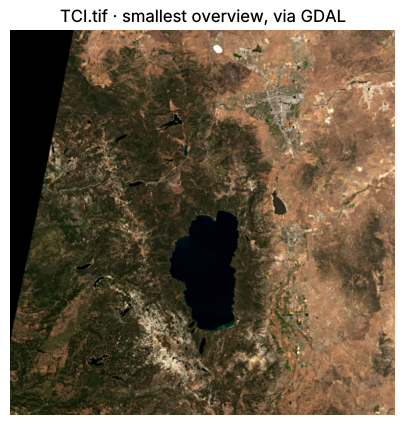

In [11]:
cog_path, cog_env = credentials.gdal_access(str(out))
with rasterio.Env(**cog_env), rasterio.open(cog_path) as src:
    print("LAYOUT:", src.tags(ns="IMAGE_STRUCTURE")["LAYOUT"])
    print("blocks:", src.block_shapes, "overviews:", src.overviews(1))
    print("dtype:", src.dtypes, "nodata:", src.nodata, "description:", src.descriptions)

s2_path, s2_env = credentials.gdal_access(SCENE + "TCI.tif")
print(s2_path, s2_env)
with rasterio.Env(**s2_env), rasterio.open(s2_path) as src:
    smallest: int = src.overviews(1)[-1]
    overview: np.ndarray = src.read(
        out_shape=(3, src.height // smallest, src.width // smallest)
    )  # (3, h, w) uint8
print(overview.shape, overview.dtype)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.moveaxis(overview, 0, -1))
ax.set_title("TCI.tif · smallest overview, via GDAL")
ax.set_axis_off()
plt.show()

## 6. Test offline with a mounted MemoryStore

`store.mount` serves a bucket root from any obstore store you build. Every `geocloud.files` and `geocloud.cog` call under that root then uses it, so code written against `s3://` runs in memory. Here `files.sync` mirrors the downloads into a fake bucket, and `write_cog` uploads straight into it.

In [12]:
FAKE: str = "s3://my-results"
store.mount(FAKE, MemoryStore())

copied: list[str | Path] = files.sync(DATA, f"{FAKE}/run-001/")
print(f"synced {len(copied)} objects")
print(
    f"second sync copies {len(files.sync(DATA, f'{FAKE}/run-001/'))}: same sizes are skipped"
)

write_cog(ndvi, f"{FAKE}/products/ndvi.tif")
for item in files.ls(FAKE):
    print(f"  {item.size / 1e3:8.0f} kB  {item.uri}")

synced 2 objects
second sync copies 0: same sizes are skipped


     44361 kB  s3://my-results/products/ndvi.tif
       364 kB  s3://my-results/run-001/goes/OR_ABI-L2-ACMM1-M6_G19_s20262811800286_e20262811800344_c20262811800455.nc
     44086 kB  s3://my-results/run-001/ndvi_tahoe.tif


The COG reader works against the mount too: open the uploaded NDVI and read one window back.

In [13]:
back: CogSource = CogSource.open(f"{FAKE}/products/ndvi.tif")
chip: GeoTensor = back.read_window(Window(0, 0, 256, 256))  # (1, 256, 256) float32
same: bool = bool(
    np.allclose(np.asarray(chip), np.asarray(ndvi)[:, :256, :256], equal_nan=True)
)
print(chip.shape, chip.dtype, "matches the written NDVI:", same)

store.unmount(FAKE)

(1, 256, 256) float32 matches the written NDVI: True


## Summary

- `credentials.set_credentials` registers access once per bucket; `gdal_access` hands the same access to GDAL.
- `files.ls`, `info`, `download` and `sync` move objects between buckets and local paths on one client pool.
- `CogSource.read_windows` reads COG windows remotely, fetching each tile once.
- `write_cog` writes a checked COG locally or to any bucket, and `store.mount` makes all of it testable offline.

Next: [geotoolz-cloud](../index.md) for the package overview and the [API reference](../api.md).